# Logistic Regression Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [4]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


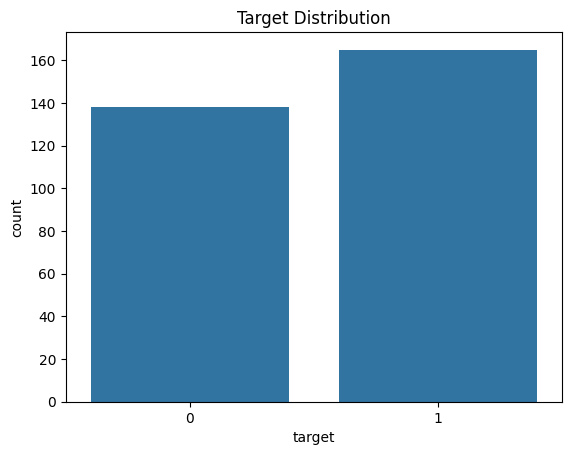

In [8]:
# Class balance
sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [9]:
X = df.drop('target', axis=1)
y = df['target']

In [10]:
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (303, 13)
y shape: (303,)


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=101
)

print(f'Train: {X_train.shape}')
print(f'Test : {X_test.shape}')

Train: (272, 13)
Test : (31, 13)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data, then transform both
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage (data knowledge leaking from the test set).**

## Logistic Regression Model

**TASK: Create a Logistic Regression model

In [14]:
from sklearn.linear_model import LogisticRegression


In [15]:
log_model = LogisticRegression(max_iter=1000)

In [16]:
log_model.fit(X_train_sc, y_train)

LogisticRegression(max_iter=1000)

### Coeffecients

**TASK: Report back the model's coefficients.**

In [17]:
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient')

print(coef_df.to_string(index=False))

 Feature  Coefficient
      ca    -0.850807
     sex    -0.734596
    thal    -0.574687
 oldpeak    -0.527225
   exang    -0.428235
trestbps    -0.262495
    chol    -0.212186
     age    -0.072445
     fbs     0.045964
 restecg     0.120366
   slope     0.380981
 thalach     0.433264
      cp     0.893714


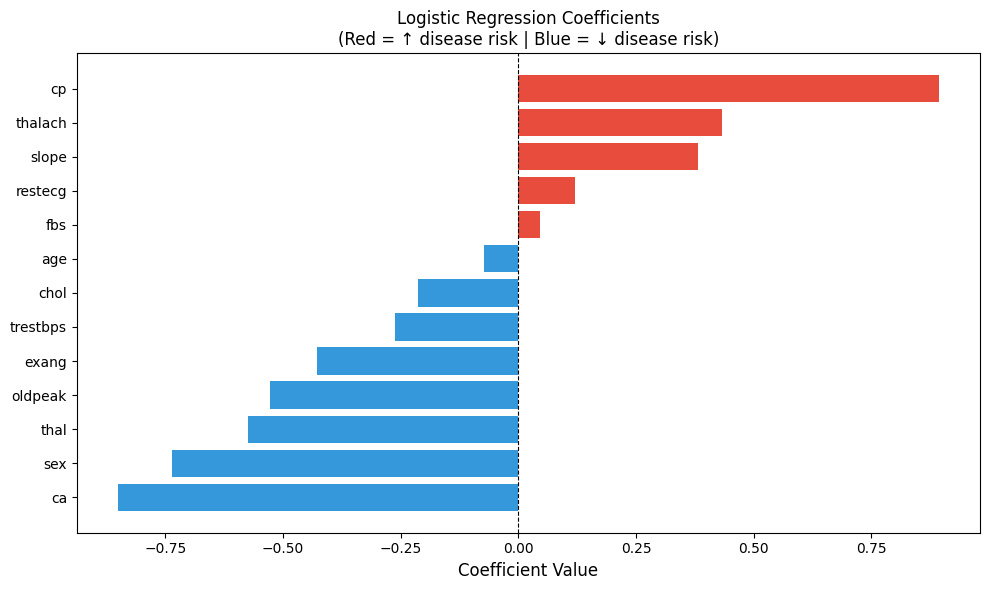

In [18]:
# Visualise coefficients
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Logistic Regression Coefficients\n(Red = ↑ disease risk | Blue = ↓ disease risk)', fontsize=12)
plt.tight_layout()
plt.show()

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [20]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score)

y_pred = log_model.predict(X_test_sc)
y_pred_proba = log_model.predict_proba(X_test_sc)[:, 1]

In [21]:
# Confusion Matrix Array
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[12  3]
 [ 2 14]]


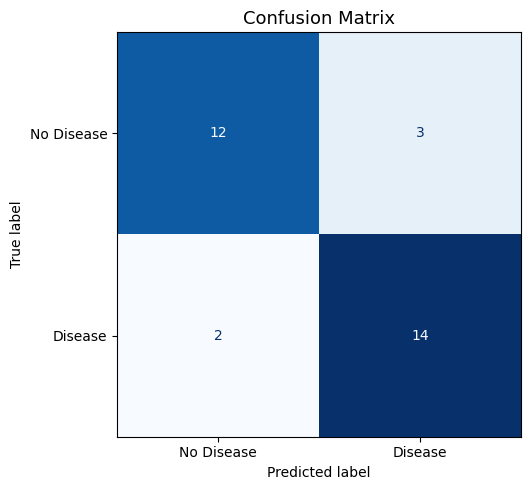

In [22]:
# Confusion Matrix Plot
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=['No Disease','Disease']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# Classification Report
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Accuracy: 0.8387

              precision    recall  f1-score   support

  No Disease       0.86      0.80      0.83        15
     Disease       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



### Performance Curves

**TASK: Create the ROC Curve.**

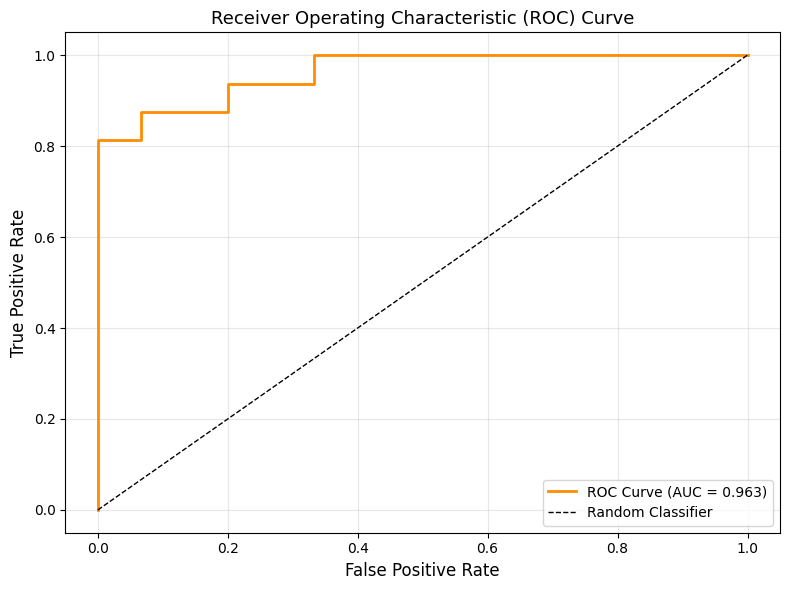

In [24]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [25]:
# Patient feature array (in same column order as training data)
patient = np.array([[48.0, 0.0, 2.0, 130.0, 275.0,
                     0.0, 1.0, 139.0, 0.0, 0.2, 2.0, 0.0, 2.0]])

# Scale using the SAME scaler fitted on training data
patient_scaled = scaler.transform(patient)

# Predict
prediction  = log_model.predict(patient_scaled)[0]
probability = log_model.predict_proba(patient_scaled)[0]

print('=' * 45)
print(f'  PREDICTION : {"Heart Disease PRESENT ✓" if prediction == 1 else "No Heart Disease"}')
print('-' * 45)
print(f'  P(No Disease) : {probability[0]*100:.1f}%')
print(f'  P(Disease)    : {probability[1]*100:.1f}%')
print(f'  Confidence    : {max(probability)*100:.1f}%')
print('=' * 45)

  PREDICTION : Heart Disease PRESENT ✓
---------------------------------------------
  P(No Disease) : 2.0%
  P(Disease)    : 98.0%
  Confidence    : 98.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


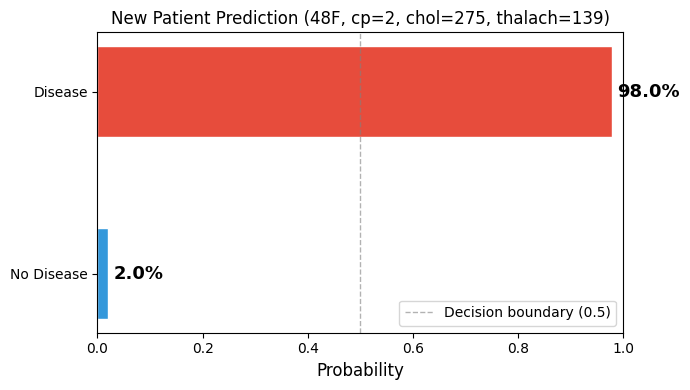

In [26]:
# Visualise prediction confidence
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(['No Disease', 'Disease'], probability,
               color=['#3498db','#e74c3c'], edgecolor='white', height=0.5)
ax.set_xlim(0, 1)
ax.set_xlabel('Probability', fontsize=12)
ax.set_title('New Patient Prediction (48F, cp=2, chol=275, thalach=139)', fontsize=12)
for bar, prob in zip(bars, probability):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'{prob*100:.1f}%', va='center', fontsize=13, fontweight='bold')
ax.axvline(0.5, color='gray', linestyle='--', lw=1, alpha=0.6, label='Decision boundary (0.5)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
### Interpretation

> **The model predicts heart disease IS present with 98.0% confidence.**
>
> Key factors driving this prediction for this patient:
> - `cp = 2` (atypical angina) — strongest positive predictor
> - `slope = 2` — upsloping ST segment associated with disease
> - `thalach = 139` — moderate max heart rate
> - `ca = 0`, `exang = 0`, `sex = 0` (female) — these individually lower risk, but are outweighed by the other features